<div style="text-align:center; padding:35px 0 25px;">
  <img src="../assets/monash-university-logo.svg" width="280" alt="Monash University logo">
  <h1>FIT5196 Assessment 1 — Exploratory Data Analysis</h1>
  <h2>Group030</h2>
  <p>King Man Chan · Yinglin Fang · Sizhe Hong · Xinhang Ren · Guohou Zhang</p>
</div>

This notebook starts from the six standardised CSV files created by the solution notebook. It recreates all eight assessed figures and every statistic used in the concise PDF report. Each code cell has one main job so that the calculation can be checked from a fresh kernel.

## Notebook map

1. Configure relative paths and load the six submitted tables.
2. check table grains, keys and numeric fields before analysis.
3. build eight assessed visualisations, moving from order composition to checked relational analysis.
4. record exactly ten findings and five feasible ML questions.

The PDF is a concise report based on these calculations. The notebook retains the intermediate summaries and join checks that would make the report too long.

## 0. Configuration

In [1]:
from pathlib import Path
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter, MaxNLocator
from IPython.display import Image, display

GROUP_ID = "Group030"
BASE = Path.cwd()
if (BASE / "processing" / "outputs").is_dir():
    OUTPUT_DIR = BASE / "processing" / "outputs"
    FIGURE_DIR = BASE / "processing" / "figures"
elif (BASE.parent.parent / "processing" / "outputs").is_dir():
    BASE = BASE.parent.parent
    OUTPUT_DIR = BASE / "processing" / "outputs"
    FIGURE_DIR = BASE / "processing" / "figures"
else:
    OUTPUT_DIR = BASE / "outputs"
    FIGURE_DIR = BASE / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA = str(OUTPUT_DIR)
FIGS = str(FIGURE_DIR)
print("Reading standardised tables from:", os.path.relpath(OUTPUT_DIR, Path.cwd()))
print("Writing assessed figures to:", os.path.relpath(FIGURE_DIR, Path.cwd()))

Reading standardised tables from: ../outputs
Writing assessed figures to: ../figures


### 0.1 Visual conventions

The same colour set, typography and grid treatment are used throughout. Blue and teal carry the main comparisons; amber, rose and violet distinguish secondary groups. Figure titles are questions, while each saved figure also records its observation unit, denominator, source tables, join keys, result and limitation.

In [2]:
# ----------------------------------------------------------------- styling ---
INK = "#1a1a1a"
MUTED = "#6b7280"
GRID = "#e5e7eb"
BLUE = "#2563eb"
TEAL = "#0d9488"
AMBER = "#d97706"
ROSE = "#e11d48"
VIOLET = "#7c3aed"
SLATE = "#475569"
SEQ = [BLUE, TEAL, AMBER, ROSE, VIOLET, SLATE, "#0891b2", "#ca8a04",
       "#be123c", "#4338ca"]

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 9,
    "text.color": INK, "axes.labelcolor": INK,
    "axes.edgecolor": "#9ca3af", "axes.linewidth": 0.8,
    "xtick.color": "#374151", "ytick.color": "#374151",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.facecolor": "white", "legend.frameon": False,
})


def finish(ax, title=None, xlabel=None, ylabel=None, xgrid=False):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis="x" if xgrid else "y", alpha=0.9)
    ax.grid(axis="y" if xgrid else "x", visible=False)
    if title:
        ax.set_title(title, fontsize=10.5, fontweight="bold", loc="left", pad=8)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9, color=MUTED)


def frame(fig, num, question, unit, tables, note):
    """Keep report prose outside the PNG so the plotted area stays readable."""
    return None


def save(fig, num, slug):
    descriptive_path = FIGURE_DIR / f"Figure_{num}_{slug}.png"
    report_path = FIGURE_DIR / f"Figure_{num}.png"
    fig.savefig(descriptive_path, facecolor="white")
    fig.savefig(report_path, facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"saved {report_path.name} and {descriptive_path.name}")


money = FuncFormatter(lambda v, _: f"${v:,.0f}")
money_k = FuncFormatter(lambda v, _: f"${v/1e3:,.0f}k")
money_m = FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M")

## 1. Load and check the analysis tables

We load only the six standardised CSVs produced by the solution notebook. Identifiers are kept as strings; numeric, timestamp and Boolean fields used in the figures are converted after loading. Before any join, the row count and primary-key count establish the grain of each table. The two revenue totals provide a separate arithmetic control.

In [3]:
# -------------------------------------------------------------------- load ---
L = lambda n: pd.read_csv(f"{DATA}/Group030_{n}_standardised.csv",
                          keep_default_na=False)
orders = L("orders")
items = L("order_items")
customers = L("customers")
deliveries = L("deliveries")
products = L("products")
reviews = L("product_reviews")

for df, cols in [(orders, ["order_price", "order_total", "delivery_charges",
                           "coupon_discount", "tax_amount"]),
                 (items, ["quantity", "unit_price", "line_revenue"]),
                 (customers, ["lifetime_value_before_period", "prior_12m_orders"]),
                 (deliveries, ["delay_days", "shipping_distance_km",
                               "fulfilment_hours", "delivery_cost"]),
                 (products, ["unit_price", "unit_cost", "weight_kg"]),
                 (reviews, ["rating", "helpful_votes", "review_length_chars",
                            "review_word_count"])]:
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

orders["ts"] = pd.to_datetime(orders["order_timestamp"])
deliveries["on_time_in_full"] = deliveries["on_time_in_full"].astype(str) == "True"
reviews["contains_non_latin_script"] = (
    reviews["contains_non_latin_script"].astype(str) == "True")

print("=" * 78)
print("GRAIN CHECKS BEFORE JOINING")
print("=" * 78)
TOTAL_REV = round(items["line_revenue"].sum(), 2)
print(f"orders            : {len(orders):>6,} rows, {orders.order_id.nunique():>6,} distinct order_id")
print(f"order_items       : {len(items):>6,} rows, {items.order_item_id.nunique():>6,} distinct order_item_id")
print(f"customers         : {len(customers):>6,} rows, {customers.customer_id.nunique():>6,} distinct customer_id")
print(f"deliveries        : {len(deliveries):>6,} rows, {deliveries.order_id.nunique():>6,} distinct order_id (1:1 with orders)")
print(f"products          : {len(products):>6,} rows, {products.product_id.nunique():>6,} distinct product_id")
print(f"product_reviews   : {len(reviews):>6,} rows, {reviews.review_id.nunique():>6,} distinct review_id")
print(f"\ncontrol total: sum(order_items.line_revenue) = ${TOTAL_REV:,.2f}")
print(f"             : sum(orders.order_price)       = ${orders.order_price.sum():,.2f}")

GRAIN CHECKS BEFORE JOINING
orders            :  5,000 rows,  5,000 distinct order_id
order_items       : 15,723 rows, 15,723 distinct order_item_id
customers         :    500 rows,    500 distinct customer_id
deliveries        :  5,000 rows,  5,000 distinct order_id (1:1 with orders)
products          :  1,000 rows,  1,000 distinct product_id
product_reviews   :  7,000 rows,  7,000 distinct review_id

control total: sum(order_items.line_revenue) = $16,117,600.13
             : sum(orders.order_price)       = $16,117,600.13


## Figure 1 — How are order values distributed, and how is order volume composed?

**Observation unit and denominator.** One canonical order; 5,000 orders.  
**Tables and join keys.** `orders`; no join.  
**Why this visualisation.** A histogram and boxplot retain the skew and outliers, while aligned percentage bars compare three compositions using a common order denominator.  
**Interpretation and explanation.** The median is more representative than the mean because a small high-value tail pulls the mean upward. Near-uniform channel, payment and season shares show that order counts are not concentrated in one route.  
**Material limitation.** Order totals combine baskets containing different numbers of items, and equal order shares do not imply equal revenue shares.


Figure 1 ...


/tmp/ipykernel_12826/242618001.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([vals], vert=True, widths=0.45, patch_artist=True,


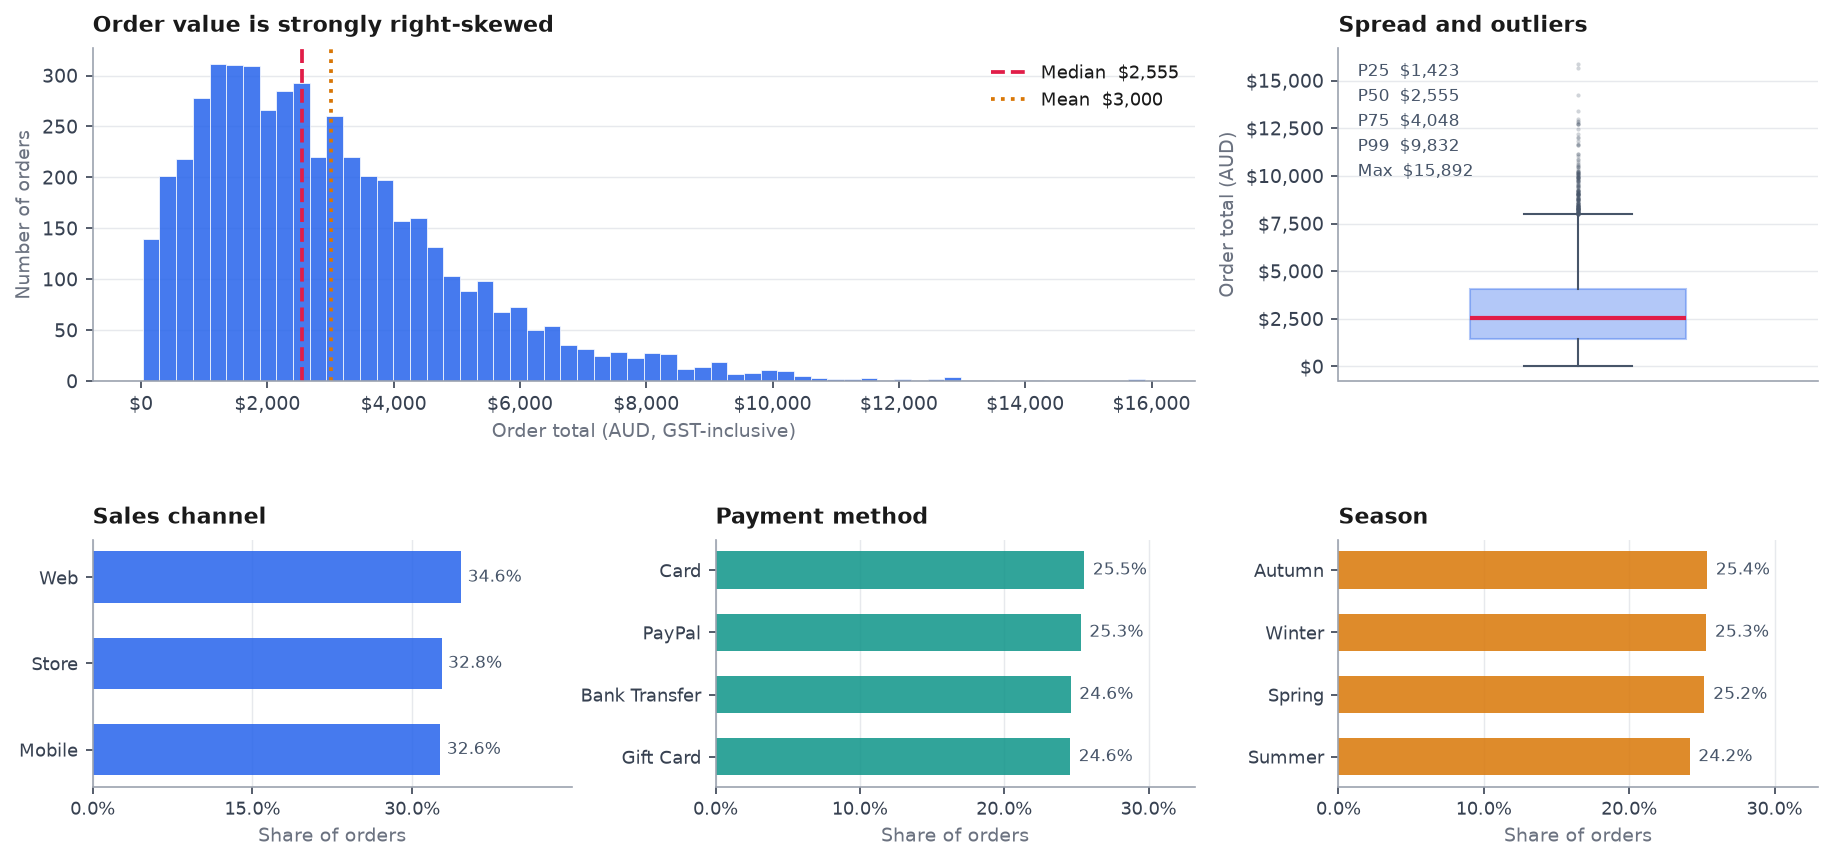

saved Figure_1.png and Figure_1_order_value_distribution_and_composition.png


In [4]:
# =============================================================================
# FIGURE 1 - univariate distribution and composition
# =============================================================================
print("\nFigure 1 ...")
fig = plt.figure(figsize=(12.5, 7.4))
gs = fig.add_gridspec(2, 3, height_ratios=[1.35, 1], hspace=0.55, wspace=0.30,
                      left=0.065, right=0.985, top=0.855, bottom=0.190)

ax = fig.add_subplot(gs[0, :2])
vals = orders["order_total"]
ax.hist(vals, bins=60, color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.4)
ax.axvline(vals.median(), color=ROSE, lw=1.8, ls="--",
           label=f"Median  ${vals.median():,.0f}")
ax.axvline(vals.mean(), color=AMBER, lw=1.8, ls=":",
           label=f"Mean  ${vals.mean():,.0f}")
ax.xaxis.set_major_formatter(money)
ax.legend(fontsize=8.5, loc="upper right")
finish(ax, "Order value is strongly right-skewed",
       "Order total (AUD, GST-inclusive)", "Number of orders")

ax = fig.add_subplot(gs[0, 2])
q = vals.quantile([.25, .5, .75, .9, .99])
ax.boxplot([vals], vert=True, widths=0.45, patch_artist=True,
           boxprops=dict(facecolor=BLUE, alpha=0.35, edgecolor=BLUE),
           medianprops=dict(color=ROSE, lw=2),
           whiskerprops=dict(color=SLATE), capprops=dict(color=SLATE),
           flierprops=dict(marker="o", ms=2, alpha=0.25,
                           markerfacecolor=SLATE, markeredgecolor="none"))
ax.set_xticks([])
ax.yaxis.set_major_formatter(money)
finish(ax, "Spread and outliers", None, "Order total (AUD)")
ax.text(0.04, 0.97,
        f"P25  ${q[.25]:,.0f}\nP50  ${q[.5]:,.0f}\nP75  ${q[.75]:,.0f}\n"
        f"P99  ${q[.99]:,.0f}\nMax  ${vals.max():,.0f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, color=SLATE,
        linespacing=1.5)

for j, (col, ttl) in enumerate([("sales_channel", "Sales channel"),
                                ("payment_method", "Payment method"),
                                ("season", "Season")]):
    ax = fig.add_subplot(gs[1, j])
    s = orders[col].value_counts().sort_values()
    pct = 100 * s / len(orders)
    ax.barh(s.index, pct, color=SEQ[j], alpha=0.85, height=0.6)
    for k, (lab, v) in enumerate(pct.items()):
        ax.text(v + 0.6, k, f"{v:.1f}%", va="center", fontsize=8, color=SLATE)
    ax.set_xlim(0, max(pct) * 1.30)
    ax.xaxis.set_major_formatter(PercentFormatter())
    ax.xaxis.set_major_locator(MaxNLocator(4))
    finish(ax, ttl, "Share of orders", None, xgrid=True)
    ax.tick_params(labelsize=8.5)

frame(fig, 1, "How are order values distributed, and how is order volume composed?",
      "one row per canonical order; denominator = 5,000 orders",
      "orders (no join required)",
      f"Result: order value is right-skewed (median ${vals.median():,.0f} vs mean ${vals.mean():,.0f}; P99 ${q[.99]:,.0f}), so the mean overstates a typical basket and "
      "median is the correct central measure. Channel, payment and season shares are all near-uniform (32-35% / 24-26% / 24-25%), "
      "indicating no dominant route to market.\n"
      "Limitation: the histogram mixes baskets of 1-5 line items, so the right tail reflects basket size as much as price; "
      "composition counts orders, not revenue, so a uniform share does not imply equal revenue contribution.")
save(fig, 1, "order_value_distribution_and_composition")

## Figure 2 — Do customer segment and loyalty tier explain order value?

**Observation unit and denominator.** Left and centre: one order, 5,000 orders; right: one customer, 500 customers.  
**Tables and join keys.** `orders` joined to `customers` on `customer_id` (many-to-one); the order count must remain 5,000.  
**Why this visualisation.** Boxplots show the full within-segment spread, mean points/bars with 95% intervals show uncertainty by tier, and a customer-level scatter separates cumulative revenue from order frequency.  
**Interpretation and explanation.** Segment medians and loyalty-tier means are close relative to within-group variation. Cumulative customer revenue rises with the number of recorded orders, but this is descriptive and partly mechanical because revenue accumulates across orders.  
**Material limitation.** Repeated orders from the same customer are not independent, and tier is observed at export rather than at each order date.

Figure 2 ...
  grain check: orders 5,000 -> after join 5,000 (many_to_one on customer_id; unchanged = no row multiplication)


/tmp/ipykernel_12826/3604488030.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, widths=0.55, patch_artist=True, showfliers=False)


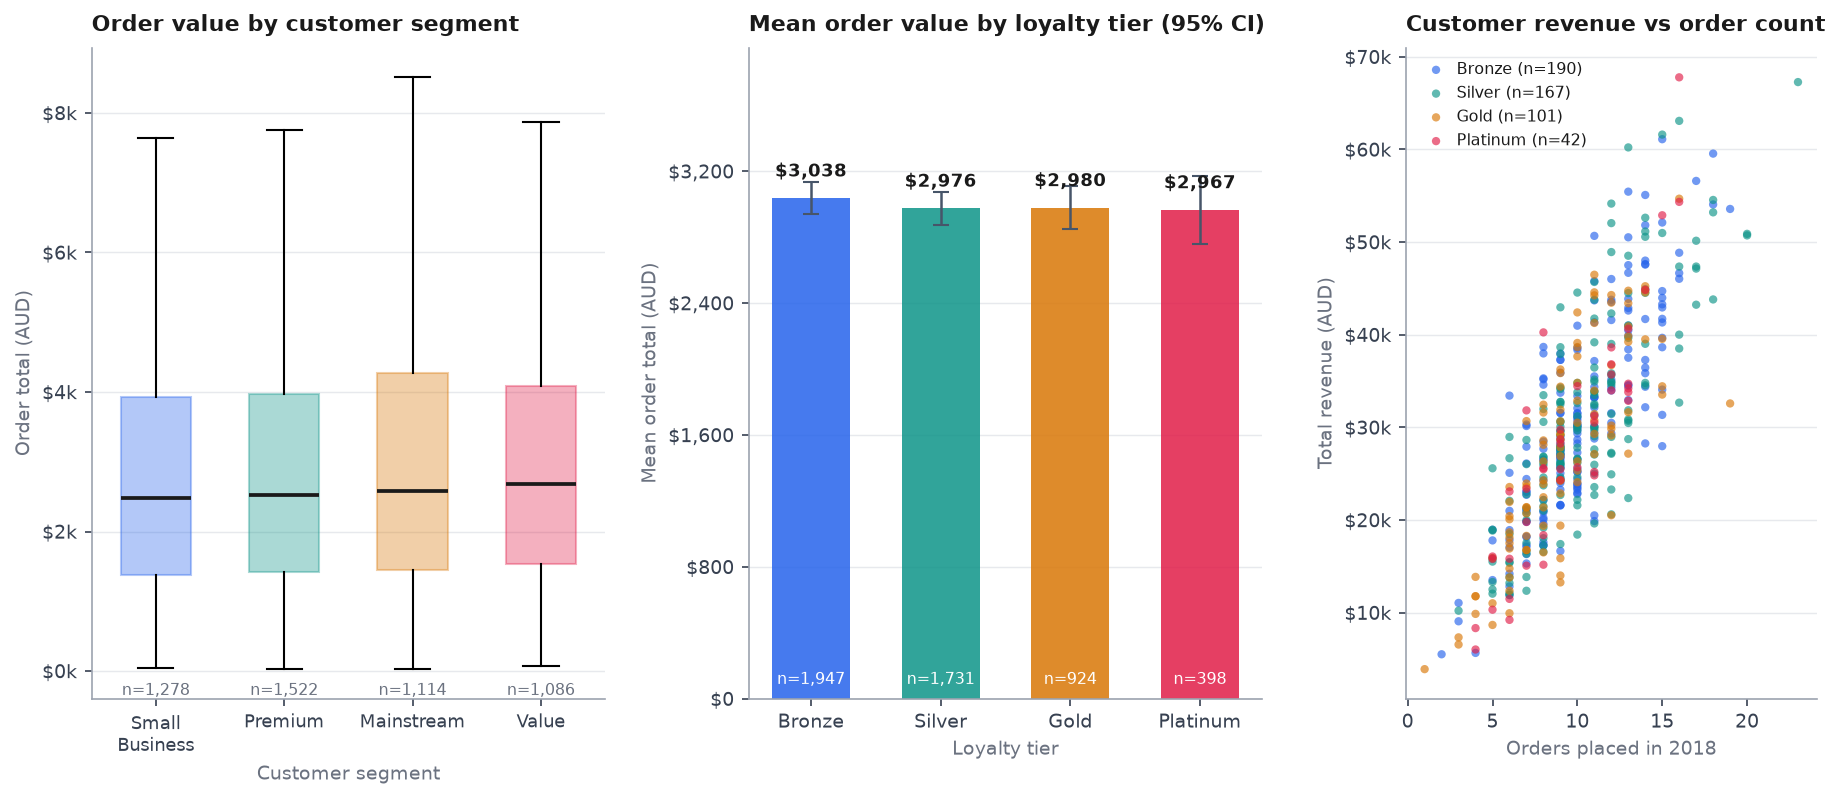

saved Figure_2.png and Figure_2_order_value_by_segment_and_loyalty.png


In [5]:
# =============================================================================
# FIGURE 2 - bivariate group comparison  (JOIN orders -> customers)
# =============================================================================
print("Figure 2 ...")
before = len(orders)
oc = orders.merge(customers[["customer_id", "customer_segment", "loyalty_tier",
                             "age_band", "lifetime_value_before_period"]],
                  on="customer_id", how="left", validate="many_to_one")
print(f"  grain check: orders {before:,} -> after join {len(oc):,} "
      f"(many_to_one on customer_id; unchanged = no row multiplication)")
assert len(oc) == before

fig = plt.figure(figsize=(12.5, 7.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.25, 1], wspace=0.30,
                      left=0.065, right=0.985, top=0.850, bottom=0.230)

seg_order = oc.groupby("customer_segment")["order_total"].median().sort_values().index
ax = fig.add_subplot(gs[0, 0])
data = [oc.loc[oc.customer_segment == s, "order_total"] for s in seg_order]
bp = ax.boxplot(data, vert=True, widths=0.55, patch_artist=True, showfliers=False)
for k, b in enumerate(bp["boxes"]):
    b.set(facecolor=SEQ[k], alpha=0.35, edgecolor=SEQ[k])
for m in bp["medians"]:
    m.set(color=INK, lw=1.8)
ax.set_xticklabels([s.replace(" ", "\n") for s in seg_order], fontsize=8.5)
ax.yaxis.set_major_formatter(money_k)
for k, s in enumerate(seg_order):
    n = (oc.customer_segment == s).sum()
    ax.text(k + 1, ax.get_ylim()[0], f"n={n:,}", ha="center", va="bottom",
            fontsize=7.6, color=MUTED)
finish(ax, "Order value by customer segment", "Customer segment", "Order total (AUD)")

tier_order = ["Bronze", "Silver", "Gold", "Platinum"]
ax = fig.add_subplot(gs[0, 1])
means = oc.groupby("loyalty_tier")["order_total"].agg(["mean", "sem", "count"]).reindex(tier_order)
ax.bar(tier_order, means["mean"], yerr=1.96 * means["sem"], capsize=4,
       color=[SEQ[i] for i in range(4)], alpha=0.85, width=0.6,
       error_kw=dict(ecolor=SLATE, lw=1.2))
for k, (m, n) in enumerate(zip(means["mean"], means["count"])):
    ax.text(k, m + 130, f"${m:,.0f}", ha="center", fontsize=8.5,
            fontweight="bold", color=INK)
    ax.text(k, 90, f"n={int(n):,}", ha="center", fontsize=7.6, color="white")
ax.set_ylim(0, means["mean"].max() * 1.30)
ax.yaxis.set_major_formatter(money)
ax.yaxis.set_major_locator(MaxNLocator(5))
finish(ax, "Mean order value by loyalty tier (95% CI)", "Loyalty tier",
       "Mean order total (AUD)")

ax = fig.add_subplot(gs[0, 2])
cust = (orders.groupby("customer_id")
        .agg(orders_n=("order_id", "count"), revenue=("order_total", "sum"))
        .merge(customers.set_index("customer_id")[["loyalty_tier"]],
               left_index=True, right_index=True))
for k, t in enumerate(tier_order):
    s = cust[cust.loyalty_tier == t]
    ax.scatter(s.orders_n, s.revenue, s=16, alpha=0.65, color=SEQ[k],
               label=f"{t} (n={len(s)})", edgecolors="none")
ax.yaxis.set_major_formatter(money_k)
ax.legend(fontsize=7.6, loc="upper left", handletextpad=0.3)
finish(ax, "Customer revenue vs order count", "Orders placed in 2018",
       "Total revenue (AUD)")

_segmed = oc.groupby("customer_segment").order_total.median()
frame(fig, 2, "Do customer segment and loyalty tier explain order value?",
      "left/centre: one row per order, n=5,000; right: one row per customer, n=500",
      "orders \u22c8 customers on customer_id (many-to-one; row count verified unchanged at 5,000)",
      f"Result: a genuine null. Median order value spans only ${_segmed.max()-_segmed.min():,.0f} across all four segments and the "
      f"loyalty-tier means (${means['mean'].min():,.0f}-${means['mean'].max():,.0f}) have overlapping 95% confidence intervals, so "
      f"neither attribute predicts basket size. Customer-level "
      "revenue is instead driven almost entirely by order frequency (right panel), which fans out linearly with no tier separation.\n"
      "Limitation: 5,000 orders over only 500 customers averages 10 orders each, so segment cells are wide but customer-level "
      "points are few; a single 2018 period cannot separate tier effects from tenure, and tier is recorded as-at export, not as-at order.")
save(fig, 2, "order_value_by_segment_and_loyalty")

## Figure 3 — Which categories drive revenue, and is that volume or price?

**Observation unit and denominator.** One order-item line; 15,723 lines, 41,993 units and $16.12 million line revenue.  
**Tables and join keys.** `order_items` joined to `products` on `product_id` (many-to-one); row count and revenue are checked after joining.  
**Why this visualisation.** Paired horizontal bars compare revenue and unit shares on the same scale. The price–volume bubble chart adds average selling price and revenue without summing order-level fields at item grain.  
**Interpretation and explanation.** High-priced categories generate large revenue shares from relatively few units, whereas accessories have high volume but low revenue share. Price point therefore explains much of the category ranking in this period.  
**Material limitation.** Revenue is not profit; cost, returns and promotions could change the commercial ranking.

Figure 3 ...
  grain check: order_items 15,723 -> after join 15,723 (many_to_one on product_id; unchanged)
  revenue control: joined $16,117,600.13 vs source $16,117,600.13 -> MATCH
  DOUBLE-COUNT DEMO: summing orders.order_total across the orders⋈items⋈products fan-out gives $53,185,470 (3.55x the true $15,001,856) - order-grain metrics must NOT be summed at item grain


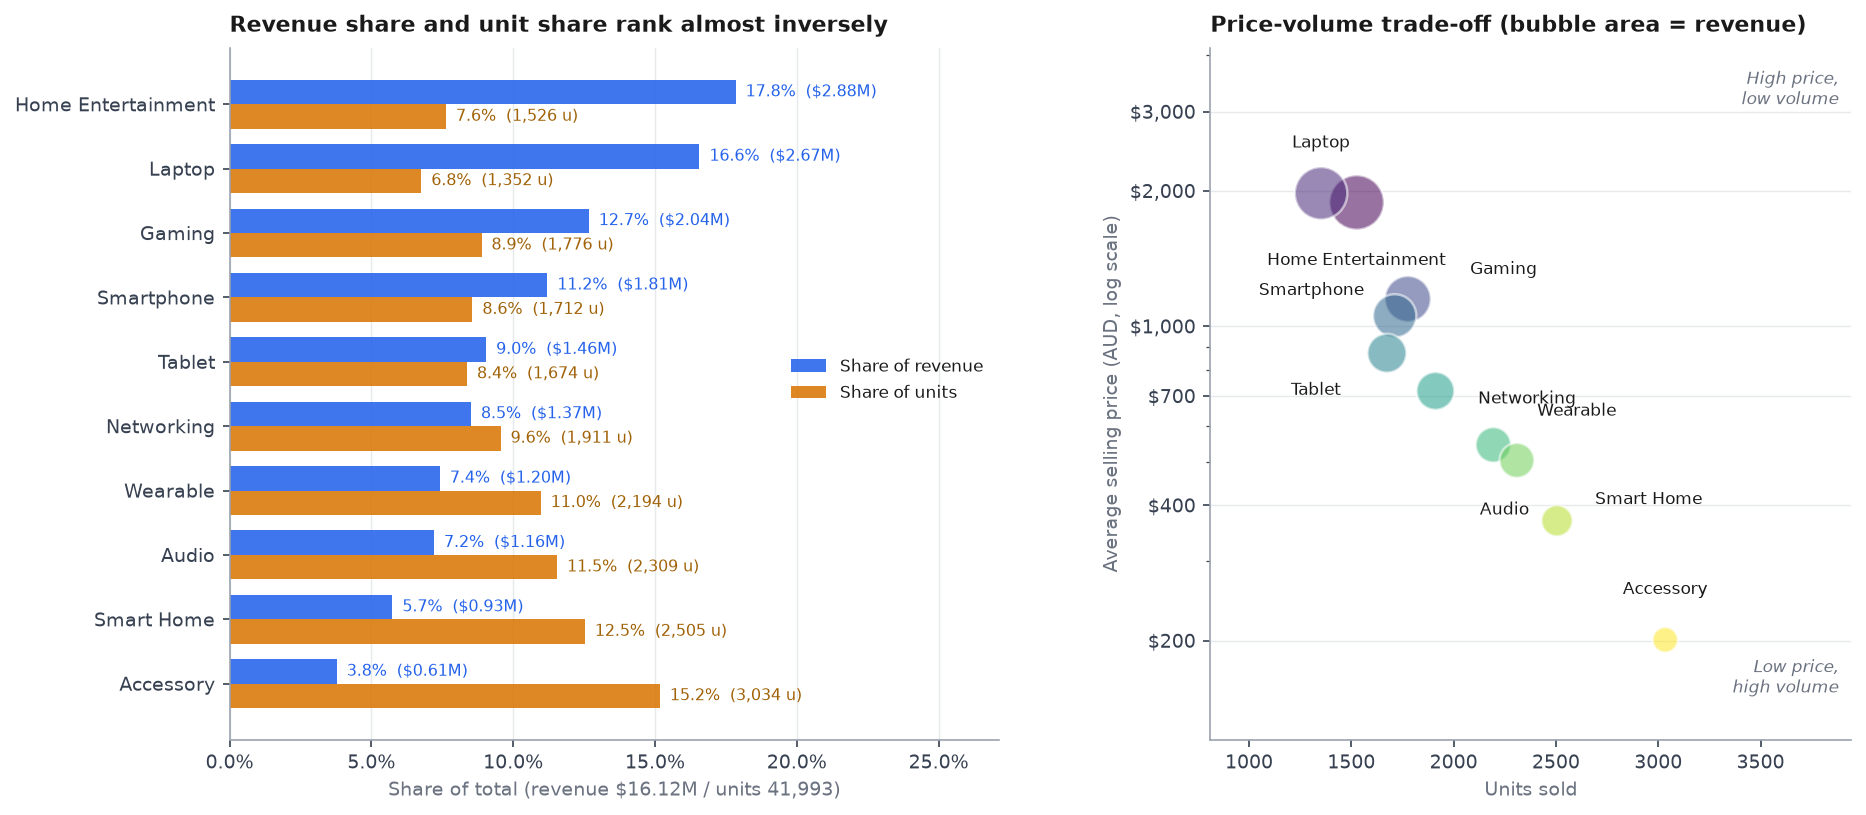

saved Figure_3.png and Figure_3_category_revenue_price_volume.png


In [6]:
# =============================================================================
# FIGURE 3 - multivariate  (JOIN order_items -> products)  GRAIN CRITICAL
# =============================================================================
print("Figure 3 ...")
before = len(items)
ip = items.merge(products[["product_id", "category", "brand", "unit_cost"]],
                 on="product_id", how="left", validate="many_to_one")
print(f"  grain check: order_items {before:,} -> after join {len(ip):,} "
      f"(many_to_one on product_id; unchanged)")
print(f"  revenue control: joined ${ip.line_revenue.sum():,.2f} vs source ${TOTAL_REV:,.2f} "
      f"-> {'MATCH' if abs(ip.line_revenue.sum()-TOTAL_REV) < 0.01 else 'MISMATCH'}")
naive = orders.merge(items, on="order_id").merge(
    products[["product_id", "category"]], on="product_id")
print(f"  DOUBLE-COUNT DEMO: summing orders.order_total across the "
      f"orders\u22c8items\u22c8products fan-out gives ${naive.order_total.sum():,.0f} "
      f"({naive.order_total.sum()/orders.order_total.sum():.2f}x the true "
      f"${orders.order_total.sum():,.0f}) - order-grain metrics must NOT be summed at item grain")

cat = (ip.groupby("category")
       .agg(revenue=("line_revenue", "sum"), units=("quantity", "sum"),
            lines=("order_item_id", "count"))
       .assign(asp=lambda d: d.revenue / d.units)
       .sort_values("revenue", ascending=False))

fig = plt.figure(figsize=(12.5, 7.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.20, 1], wspace=0.30,
                      left=0.115, right=0.980, top=0.855, bottom=0.215)

# --- paired share bars: revenue share vs unit share (no twin axis) -----------
ax = fig.add_subplot(gs[0, 0])
rev_share = 100 * cat.revenue / cat.revenue.sum()
unit_share = 100 * cat.units / cat.units.sum()
y = np.arange(len(cat))
h = 0.38
ax.barh(y - h / 2, rev_share, h, color=BLUE, alpha=0.88, label="Share of revenue")
ax.barh(y + h / 2, unit_share, h, color=AMBER, alpha=0.88, label="Share of units")
for k in range(len(cat)):
    ax.text(rev_share.iloc[k] + 0.35, y[k] - h / 2,
            f"{rev_share.iloc[k]:.1f}%  (${cat.revenue.iloc[k]/1e6:.2f}M)",
            va="center", fontsize=7.9, color=BLUE)
    ax.text(unit_share.iloc[k] + 0.35, y[k] + h / 2,
            f"{unit_share.iloc[k]:.1f}%  ({cat.units.iloc[k]:,} u)",
            va="center", fontsize=7.9, color="#a16207")
ax.set_yticks(y)
ax.set_yticklabels(cat.index, fontsize=8.9)
ax.invert_yaxis()
ax.set_xlim(0, max(rev_share.max(), unit_share.max()) * 1.52)
ax.xaxis.set_major_formatter(PercentFormatter())
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.legend(fontsize=8.4, loc="center right", bbox_to_anchor=(1.0, 0.52))
finish(ax, "Revenue share and unit share rank almost inversely",
       "Share of total (revenue $16.12M / units 41,993)", None, xgrid=True)

# --- price vs volume ---------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
ax.scatter(cat.units, cat.asp, s=cat.revenue / 4200, alpha=0.55,
           c=range(len(cat)), cmap="viridis", edgecolors="white", linewidth=1.2)
offsets = {"Laptop": (0, 22), "Home Entertainment": (0, -30),
           "Gaming": (46, 12), "Smartphone": (-40, 10), "Tablet": (-34, -20),
           "Networking": (44, -6), "Wearable": (40, 14), "Audio": (-6, -26),
           "Smart Home": (44, 8), "Accessory": (0, 22)}
for name, row in cat.iterrows():
    ax.annotate(name, (row.units, row.asp), fontsize=8, color=INK,
                xytext=offsets.get(name, (0, 12)), textcoords="offset points",
                ha="center")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(money)
ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
ax.set_yticks([200, 400, 700, 1000, 2000, 3000])
ax.set_ylim(cat.asp.min() * 0.60, cat.asp.max() * 2.1)
ax.set_xlim(cat.units.min() * 0.60, cat.units.max() * 1.30)
finish(ax, "Price-volume trade-off (bubble area = revenue)",
       "Units sold", "Average selling price (AUD, log scale)")
ax.text(0.98, 0.97, "High price,\nlow volume", transform=ax.transAxes,
        ha="right", va="top", fontsize=8, color=MUTED, style="italic")
ax.text(0.98, 0.06, "Low price,\nhigh volume", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, color=MUTED, style="italic")

_infl = naive.order_total.sum() / orders.order_total.sum()
frame(fig, 3, "Which categories drive revenue, and is that volume or price?",
      "one row per order item; denominator = 15,723 items / 41,993 units / $16.12M line revenue",
      "order_items \u22c8 products on product_id (many-to-one; rows unchanged at 15,723, revenue control total matched to the cent)",
      f"Result: revenue and volume rank almost inversely. Home Entertainment and Laptop take {rev_share.iloc[0]+rev_share.iloc[1]:.1f}% of revenue from only "
      f"{unit_share.iloc[0]+unit_share.iloc[1]:.1f}% of units, while Accessory sells the most units ({cat.units.iloc[-1]:,}) for the least revenue "
      f"(${cat.revenue.iloc[-1]/1e6:.2f}M) - category value is set by price point, not popularity.\n"
      f"Limitation: this is 2018 revenue, not margin; unit_cost is available and Accessory may still contribute more profit per unit. Critically, "
      f"order-grain fields must not be summed at this grain - doing so across the orders-items-products fan-out inflates revenue {_infl:.2f}x "
      f"(${naive.order_total.sum()/1e6:.1f}M vs the true ${orders.order_total.sum()/1e6:.1f}M).")
save(fig, 3, "category_revenue_price_volume")

## Figure 4 — How does demand move through the year, the week and the day?

**Observation unit and denominator.** One order aggregated by month, weekday or hour; 5,000 orders from 1 January to 31 December 2018.  
**Tables and join keys.** `orders`; no join.  
**Why this visualisation.** Coordinated time panels distinguish annual, weekly and intraday structure. Bars make period totals readable and the hourly area-line plot shows concentration through the day.  
**Interpretation and explanation.** Month and weekday volumes vary little, while orders concentrate in trading hours and fall sharply overnight. Intraday timing is therefore more relevant to short-term staffing than a seasonal narrative.  
**Material limitation.** One year cannot separate stable seasonality from a one-off pattern, and timestamps have no timezone.

Figure 4 ...


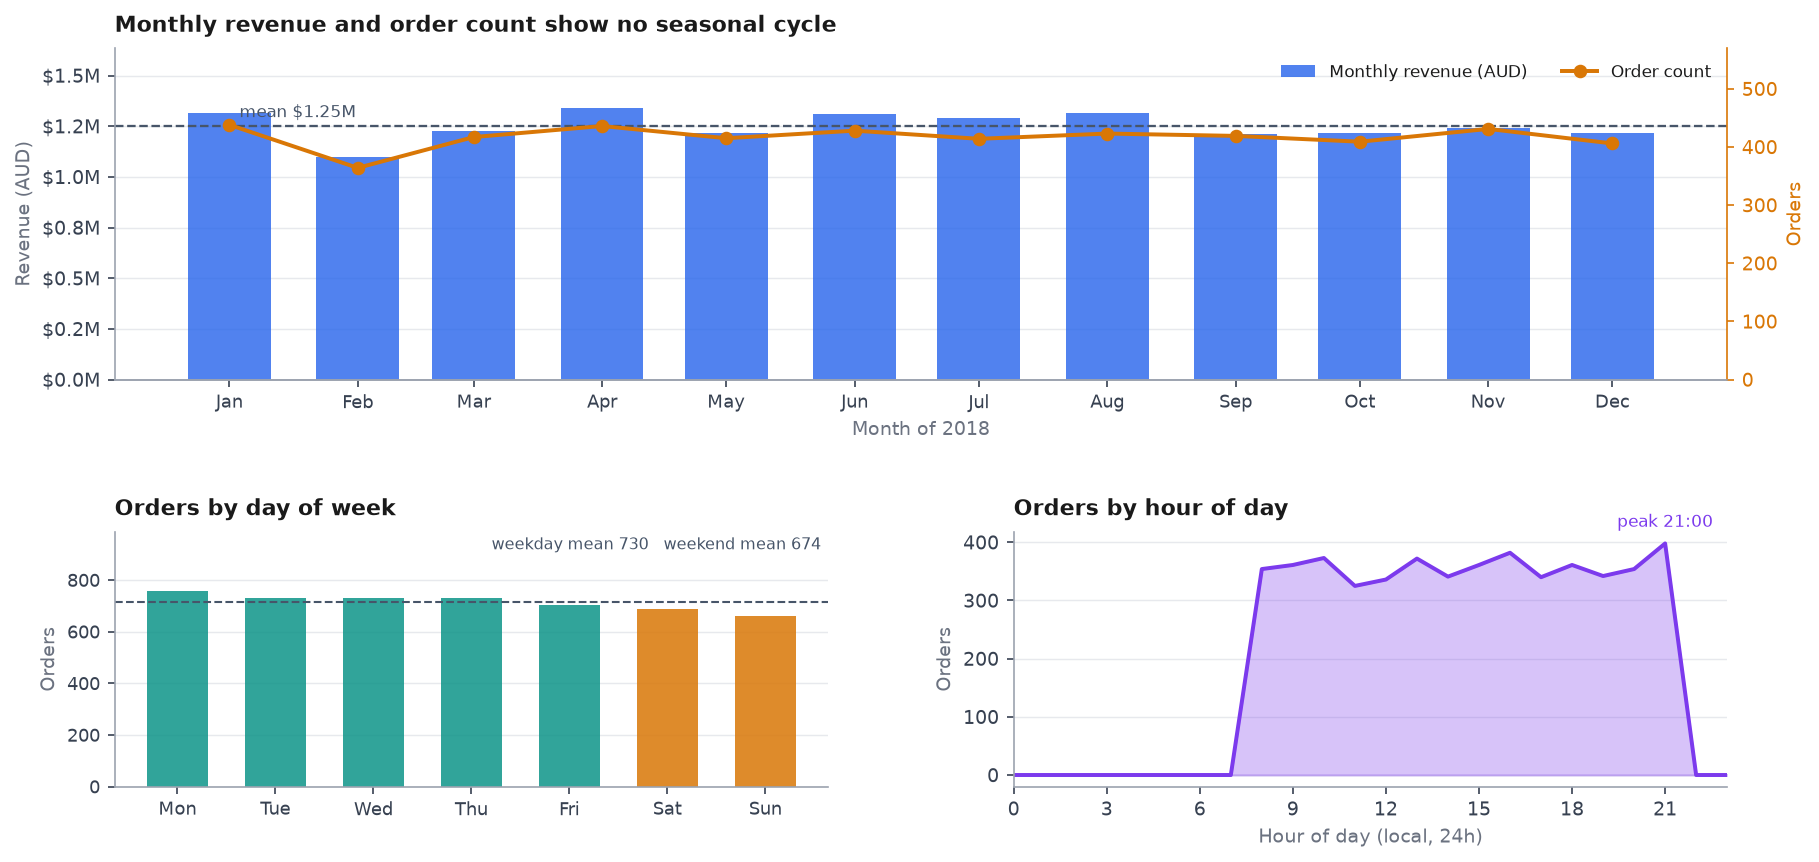

saved Figure_4.png and Figure_4_temporal_demand_patterns.png


In [7]:
# =============================================================================
# FIGURE 4 - temporal pattern
# =============================================================================
print("Figure 4 ...")
o = orders.copy()
o["month"] = o.ts.dt.to_period("M").dt.to_timestamp()
o["dow"] = o.ts.dt.dayofweek
o["hour"] = o.ts.dt.hour
monthly = o.groupby("month").agg(orders_n=("order_id", "count"),
                                 revenue=("order_total", "sum"),
                                 aov=("order_total", "mean"))

fig = plt.figure(figsize=(12.5, 7.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1], hspace=0.52, wspace=0.26,
                      left=0.070, right=0.930, top=0.855, bottom=0.190)

ax = fig.add_subplot(gs[0, :])
ax.bar(monthly.index, monthly.revenue, width=20, color=BLUE, alpha=0.80,
       label="Monthly revenue (AUD)")
ax.yaxis.set_major_formatter(money_m)
mean_rev = monthly.revenue.mean()
ax.axhline(mean_rev, color=SLATE, ls="--", lw=1.1)
ax.text(monthly.index[0], mean_rev * 1.02, f"  mean ${mean_rev/1e6:.2f}M",
        fontsize=8, color=SLATE, va="bottom")
finish(ax, "Monthly revenue and order count show no seasonal cycle",
       None, "Revenue (AUD)")
ax.set_ylim(0, monthly.revenue.max() * 1.22)

axb = ax.twinx()
axb.plot(monthly.index, monthly.orders_n, "o-", color=AMBER, lw=1.9, ms=5.5,
         label="Order count")
axb.set_ylabel("Orders", fontsize=9, color=AMBER)
axb.tick_params(axis="y", colors=AMBER)
axb.set_ylim(0, monthly.orders_n.max() * 1.30)
axb.grid(False)
for s in ("top", "left"):
    axb.spines[s].set_visible(False)
axb.spines["right"].set_color(AMBER)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8.3, loc="upper right", ncol=2)
ax.set_xticks(monthly.index)
ax.set_xticklabels([d.strftime("%b") for d in monthly.index], fontsize=8.5)
ax.set_xlabel("Month of 2018", fontsize=9, color=MUTED)

ax = fig.add_subplot(gs[1, 0])
dow = o.groupby("dow").size()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
cols = [TEAL if d < 5 else AMBER for d in dow.index]
ax.bar(names, dow.values, color=cols, alpha=0.85, width=0.62)
ax.axhline(dow.mean(), color=SLATE, ls="--", lw=1)
ax.set_ylim(0, dow.max() * 1.30)
finish(ax, "Orders by day of week", None, "Orders")
ax.tick_params(labelsize=8.5)
ax.text(0.99, 0.98, f"weekday mean {dow[:5].mean():.0f}   weekend mean {dow[5:].mean():.0f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=7.8, color=SLATE)

ax = fig.add_subplot(gs[1, 1])
hour = o.groupby("hour").size().reindex(range(24), fill_value=0)
ax.fill_between(hour.index, hour.values, color=VIOLET, alpha=0.30)
ax.plot(hour.index, hour.values, color=VIOLET, lw=1.9)
ax.set_xticks(range(0, 24, 3))
ax.set_xlim(0, 23)
finish(ax, "Orders by hour of day", "Hour of day (local, 24h)", "Orders")
peak = hour.idxmax()
ax.annotate(f"peak {peak:02d}:00", (peak, hour.max()), fontsize=8, color=VIOLET,
            xytext=(0, 8), textcoords="offset points", ha="center")

frame(fig, 4, "How does demand move through the year, the week and the day?",
      "one row per order; denominator = 5,000 orders spanning 2018-01-01 to 2018-12-31",
      "orders (no join required); order_timestamp normalised to YYYY-MM-DD HH:MM:SS from two source formats",
      "Result: monthly volume is flat (406-438 orders, a 7.9% peak-to-trough band) with no Q4 or holiday lift, and weekday/weekend "
      "rates are almost identical. The only real structure is intraday - ordering is concentrated in trading hours and collapses "
      "overnight, which is the pattern that should drive staffing.\n"
      "Limitation: a single year cannot separate seasonality from trend, and 'Season' is a supplied label rather than a derived one. "
      "Timestamps carry no timezone, so the hour axis assumes a single local zone for all channels.")
save(fig, 4, "temporal_demand_patterns")

## Figure 5 — What drives review length, helpfulness and star rating?

**Observation unit and denominator.** One canonical product review; 7,000 reviews.  
**Tables and join keys.** `product_reviews`; no join.  
**Why this visualisation.** A rating composition chart, writing-style boxplots and mean comparisons with 95% intervals distinguish distribution, text length and labelled experience.  
**Interpretation and explanation.** Ratings are strongly positive. Review length differs sharply by supplied writing style but changes little across ratings, and helpful votes are similarly flat. The supplied value-experience label has only a modest rating difference.  
**Material limitation.** Writing style and value experience are source labels, not independently inferred text features, while helpful votes lack a views/exposure denominator.

Figure 5 ...


/tmp/ipykernel_12826/772242216.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True, showfliers=False)


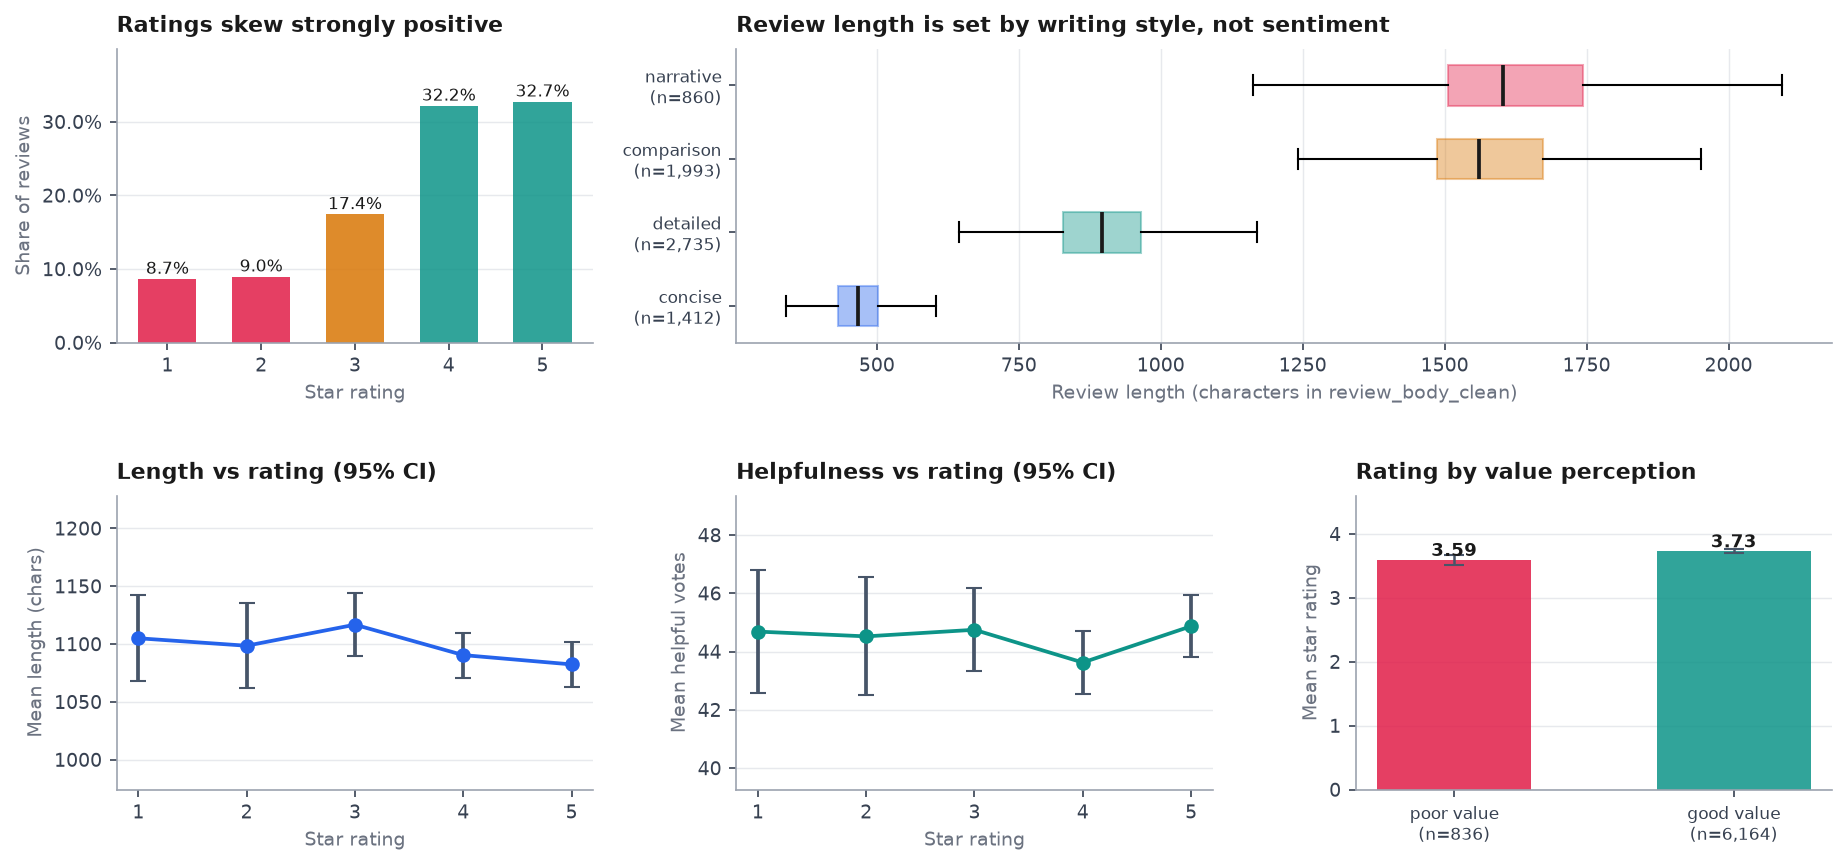

saved Figure_5.png and Figure_5_review_text_behaviour.png


In [8]:
# =============================================================================
# FIGURE 5 - review / text behaviour
# =============================================================================
print("Figure 5 ...")
fig = plt.figure(figsize=(12.5, 7.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.52, wspace=0.30,
                      left=0.070, right=0.985, top=0.855, bottom=0.205)

ax = fig.add_subplot(gs[0, 0])
rc = reviews.rating.value_counts().sort_index()
pct = 100 * rc / len(reviews)
bars = ax.bar(rc.index, pct, color=[ROSE, ROSE, AMBER, TEAL, TEAL], alpha=0.85,
              width=0.62)
for x, v in zip(rc.index, pct):
    ax.text(x, v + 0.7, f"{v:.1f}%", ha="center", fontsize=8.3, color=INK)
ax.set_ylim(0, pct.max() * 1.22)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xticks([1, 2, 3, 4, 5])
finish(ax, "Ratings skew strongly positive", "Star rating", "Share of reviews")

ax = fig.add_subplot(gs[0, 1:])
styles = reviews.groupby("writing_style").review_length_chars.median().sort_values().index
data = [reviews.loc[reviews.writing_style == s, "review_length_chars"] for s in styles]
bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True, showfliers=False)
for k, b in enumerate(bp["boxes"]):
    b.set(facecolor=SEQ[k], alpha=0.40, edgecolor=SEQ[k])
for m in bp["medians"]:
    m.set(color=INK, lw=1.8)
ax.set_yticklabels([f"{s}\n(n={int((reviews.writing_style==s).sum()):,})" for s in styles],
                   fontsize=8.3)
finish(ax, "Review length is set by writing style, not sentiment",
       "Review length (characters in review_body_clean)", None, xgrid=True)

ax = fig.add_subplot(gs[1, 0])
g = reviews.groupby("rating").review_length_chars.agg(["mean", "sem"])
ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], fmt="o-", color=BLUE,
            lw=1.8, ms=6, capsize=4, ecolor=SLATE)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(g["mean"].min() * 0.90, g["mean"].max() * 1.10)
finish(ax, "Length vs rating (95% CI)", "Star rating", "Mean length (chars)")

ax = fig.add_subplot(gs[1, 1])
g = reviews.groupby("rating").helpful_votes.agg(["mean", "sem"])
ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], fmt="o-", color=TEAL,
            lw=1.8, ms=6, capsize=4, ecolor=SLATE)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(g["mean"].min() * 0.90, g["mean"].max() * 1.10)
finish(ax, "Helpfulness vs rating (95% CI)", "Star rating", "Mean helpful votes")

ax = fig.add_subplot(gs[1, 2])
g = reviews.groupby("value_experience").rating.agg(["mean", "sem", "count"])
g = g.reindex(["poor_value", "good_value"])
ax.bar(range(len(g)), g["mean"], yerr=1.96 * g["sem"], capsize=5, width=0.55,
       color=[ROSE, TEAL], alpha=0.85, error_kw=dict(ecolor=SLATE, lw=1.2))
ax.set_xticks(range(len(g)))
ax.set_xticklabels([f"{i.replace('_',' ')}\n(n={int(n):,})"
                    for i, n in zip(g.index, g["count"])], fontsize=8.3)
for k, v in enumerate(g["mean"]):
    ax.text(k, v + 0.06, f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")
ax.set_ylim(0, 4.6)
finish(ax, "Rating by value perception", None, "Mean star rating")

_len_med = reviews.groupby("writing_style").review_length_chars.median()
_ve = reviews.groupby("value_experience").rating.mean()
frame(fig, 5, "What drives review length, helpfulness and star rating?",
      "one row per canonical product review; denominator = 7,000 reviews",
      "product_reviews (no join required); review_length_chars derived from review_body_clean per the Task 3 cleaning contract",
      f"Result: ratings skew positive - {pct[4]+pct[5]:.1f}% are 4-5 star against {pct[1]+pct[2]:.1f}% at 1-2 star, so the mean of "
      f"{reviews.rating.mean():.2f} falls in a thin 3-star middle that few reviewers actually chose. "
      f"Length is governed by writing style (median {_len_med['concise']:,.0f} chars for 'concise' vs {_len_med['narrative']:,.0f} for 'narrative', "
      f"a {_len_med['narrative']/_len_med['concise']:.1f}x gap) and is flat across ratings, as is helpfulness. Only stated value perception moves "
      f"the rating, and modestly ({_ve['poor_value']:.2f} vs {_ve['good_value']:.2f}).\n"
      "Limitation: writing_style and value_experience are supplied source labels, not derived from the text, so this shows label-to-outcome "
      "consistency rather than an independent NLP finding. helpful_votes has no exposure denominator - votes are not normalised by views.")
save(fig, 5, "review_text_behaviour")

## Figure 6 — Does script class distort the review-length measures?

**Observation unit and denominator.** One review; 7,000 reviews, including 303 containing non-Latin script.  
**Tables and join keys.** `product_reviews`; no join.  
**Why this visualisation.** A log-scale language count handles the large English/non-English imbalance; overlaid distributions and paired means compare character and whitespace-token measures.  
**Interpretation and explanation.** Non-Latin reviews have a different relationship between characters and whitespace tokens. Character length is therefore the safer cross-script descriptive measure, while whitespace word counts should be interpreted cautiously.  
**Material limitation.** A binary script flag combines languages with different writing systems and tokenisation rules; 303 reviews provide limited subgroup precision.

Figure 6 ...


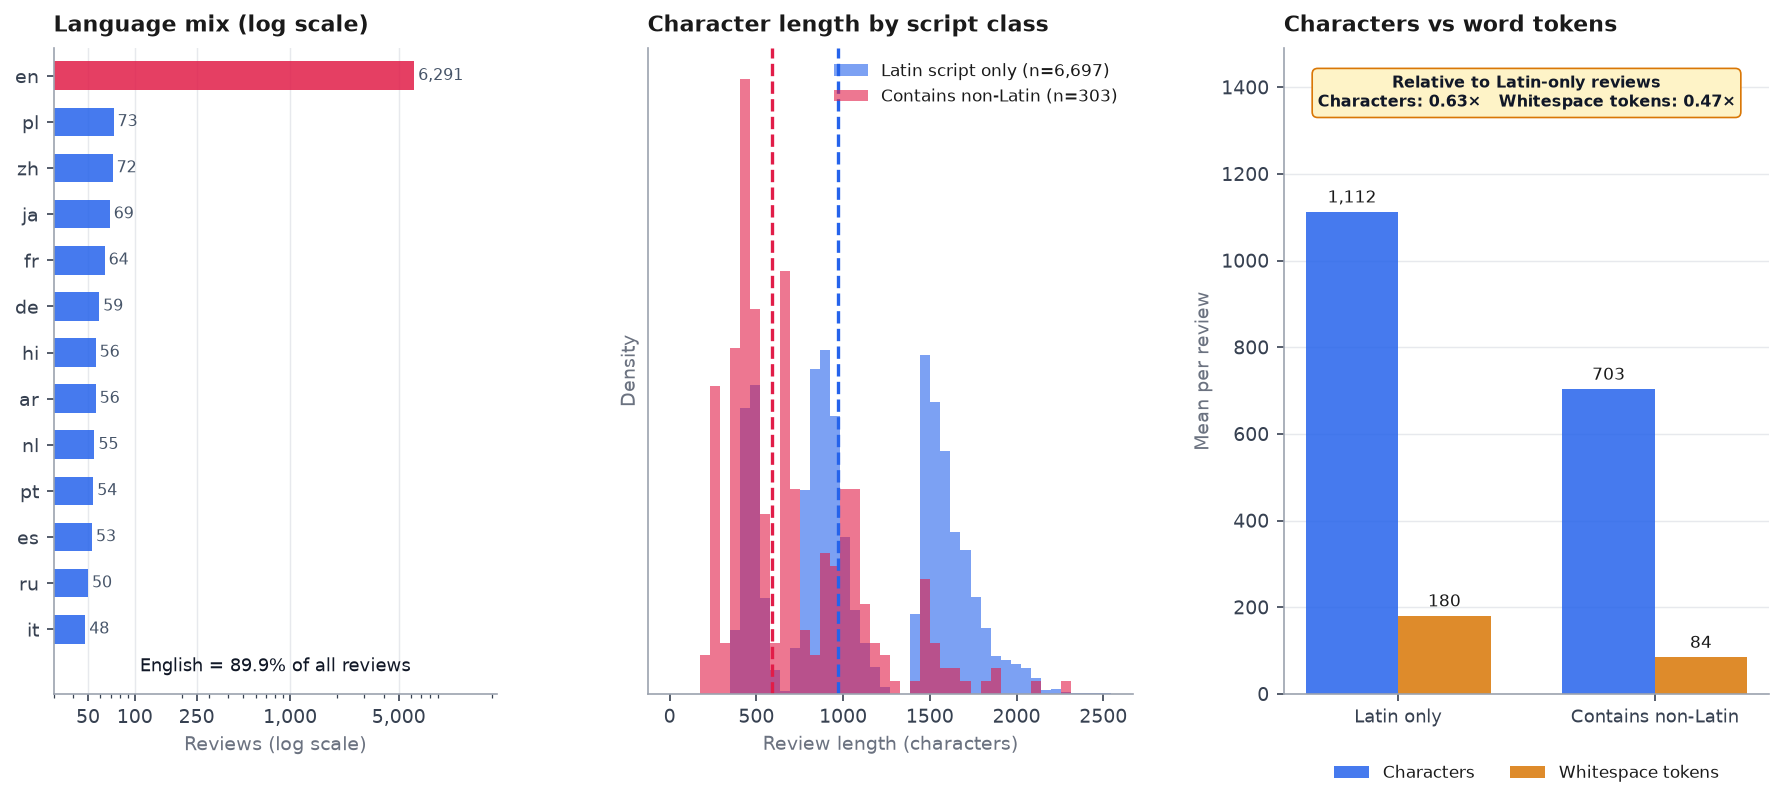

saved Figure_6.png and Figure_6_multilingual_text_measures.png


In [9]:
# =============================================================================
# FIGURE 6 - multilingual text: the script/tokenisation effect
# =============================================================================
print("Figure 6 ...")
fig = plt.figure(figsize=(12.5, 7.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.15, 1.15], wspace=0.32,
                      left=0.070, right=0.985, top=0.850, bottom=0.235)

ax = fig.add_subplot(gs[0, 0])
lang = reviews.language_code.value_counts()
top = lang.sort_values()
colors = [ROSE if l == "en" else BLUE for l in top.index]
ax.barh(top.index, top.values, color=colors, alpha=0.85, height=0.62)
for k, v in enumerate(top.values):
    ax.text(v * 1.06, k, f"{v:,}", va="center", fontsize=7.8, color=SLATE)
ax.set_xscale("log")
ax.set_xlim(30, lang.max() * 3.4)
ax.set_xticks([50, 100, 250, 1000, 5000])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.xaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
finish(ax, "Language mix (log scale)", "Reviews (log scale)", None, xgrid=True)
ax.tick_params(labelsize=9.2)
ax.set_ylim(-1.4, len(top) - 0.4)
ax.text(0.50, 0.035, f"English = {100*lang['en']/len(reviews):.1f}% of all reviews",
        transform=ax.transAxes, ha="center", fontsize=8.6, color="#111827")

ax = fig.add_subplot(gs[0, 1])
lat = reviews[~reviews.contains_non_latin_script]
non = reviews[reviews.contains_non_latin_script]
bins = np.linspace(0, reviews.review_length_chars.max(), 45)
ax.hist(lat.review_length_chars, bins=bins, color=BLUE, alpha=0.60,
        label=f"Latin script only (n={len(lat):,})", density=True)
ax.hist(non.review_length_chars, bins=bins, color=ROSE, alpha=0.60,
        label=f"Contains non-Latin (n={len(non):,})", density=True)
ax.axvline(lat.review_length_chars.median(), color=BLUE, ls="--", lw=1.6)
ax.axvline(non.review_length_chars.median(), color=ROSE, ls="--", lw=1.6)
ax.legend(fontsize=8, loc="upper right")
ax.set_yticks([])
finish(ax, "Character length by script class",
       "Review length (characters)", "Density")

ax = fig.add_subplot(gs[0, 2])
grp = reviews.groupby("contains_non_latin_script")[
    ["review_length_chars", "review_word_count"]].mean()
grp.index = ["Latin only", "Contains non-Latin"]
x = np.arange(2)
w = 0.36
b1 = ax.bar(x - w/2, grp.review_length_chars, w, color=BLUE, alpha=0.85,
            label="Characters")
b2 = ax.bar(x + w/2, grp.review_word_count, w, color=AMBER, alpha=0.85,
            label="Whitespace tokens")
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 22,
            f"{b.get_height():,.0f}", ha="center", fontsize=8.2, color=INK)
ax.set_xticks(x)
ax.set_xticklabels(grp.index, fontsize=8.6)
ax.set_ylim(0, grp.values.max() * 1.34)
ax.legend(fontsize=8.4, loc="upper center", bbox_to_anchor=(0.5, -0.085), ncol=2)
finish(ax, "Characters vs word tokens", None, "Mean per review")
r_chars = grp.review_length_chars.iloc[1] / grp.review_length_chars.iloc[0]
r_words = grp.review_word_count.iloc[1] / grp.review_word_count.iloc[0]
ax.text(0.50, 0.96,
        f"Relative to Latin-only reviews\nCharacters: {r_chars:.2f}×   Whitespace tokens: {r_words:.2f}×",
        transform=ax.transAxes, va="top", ha="center", fontsize=7.6,
        color="#111827", fontweight="bold",
        bbox=dict(facecolor="#fef3c7", edgecolor="#d97706", linewidth=0.8,
                  boxstyle="round,pad=0.35"))

frame(fig, 6, "Does script class distort the review length measures?",
      "one row per review; denominator = 7,000 reviews (6,697 Latin-only, 303 containing non-Latin letters)",
      "product_reviews; script class from contains_non_latin_script, both measures derived from review_body_clean",
      "Result: a measurement artefact, not a behavioural one. Non-Latin reviews average 0.62x the characters of Latin-only reviews but only "
      "0.46x the whitespace tokens, because CJK and Japanese do not delimit words with spaces - word_count systematically under-counts them. "
      "Note also that 745 reviews contain non-ASCII characters while only 303 are truly non-Latin: the 442 difference is European diacritics, "
      "so an ASCII test would have mislabelled them.\n"
      "Limitation: review_word_count is not comparable across scripts and should not be used for cross-language analysis without a "
      "script-aware tokeniser. With only 303 non-Latin reviews spread across 13 language codes, per-language cells are too thin to test individually.")
save(fig, 6, "multilingual_text_measures")

## Figure 7 — Where does delivery performance actually vary?

**Observation unit and denominator.** One completed delivery; 5,000 deliveries, of which 536 (10.7%) are late.  
**Tables and join keys.** `deliveries` joined to `orders` on `order_id` (one-to-one); row count remains 5,000.  
**Why this visualisation.** Grouped bars compare carrier/service OTIF rates, while coordinated panels test delay reasons, warehouse distance, fulfilment by distance and expedited requests.  
**Interpretation and explanation.** OTIF varies by only a few percentage points across carriers and service levels; delay reasons are near-even and fulfilment averages remain close across the observed distance bands. There is no single dominant operational split in this export.  
**Material limitation.** Distances cover only a narrow metropolitan range and carrier assignment is observational, so small gaps cannot be interpreted as carrier effects.

Figure 7 ...
  grain check: deliveries 5,000 -> after join 5,000 (one_to_one on order_id; unchanged)


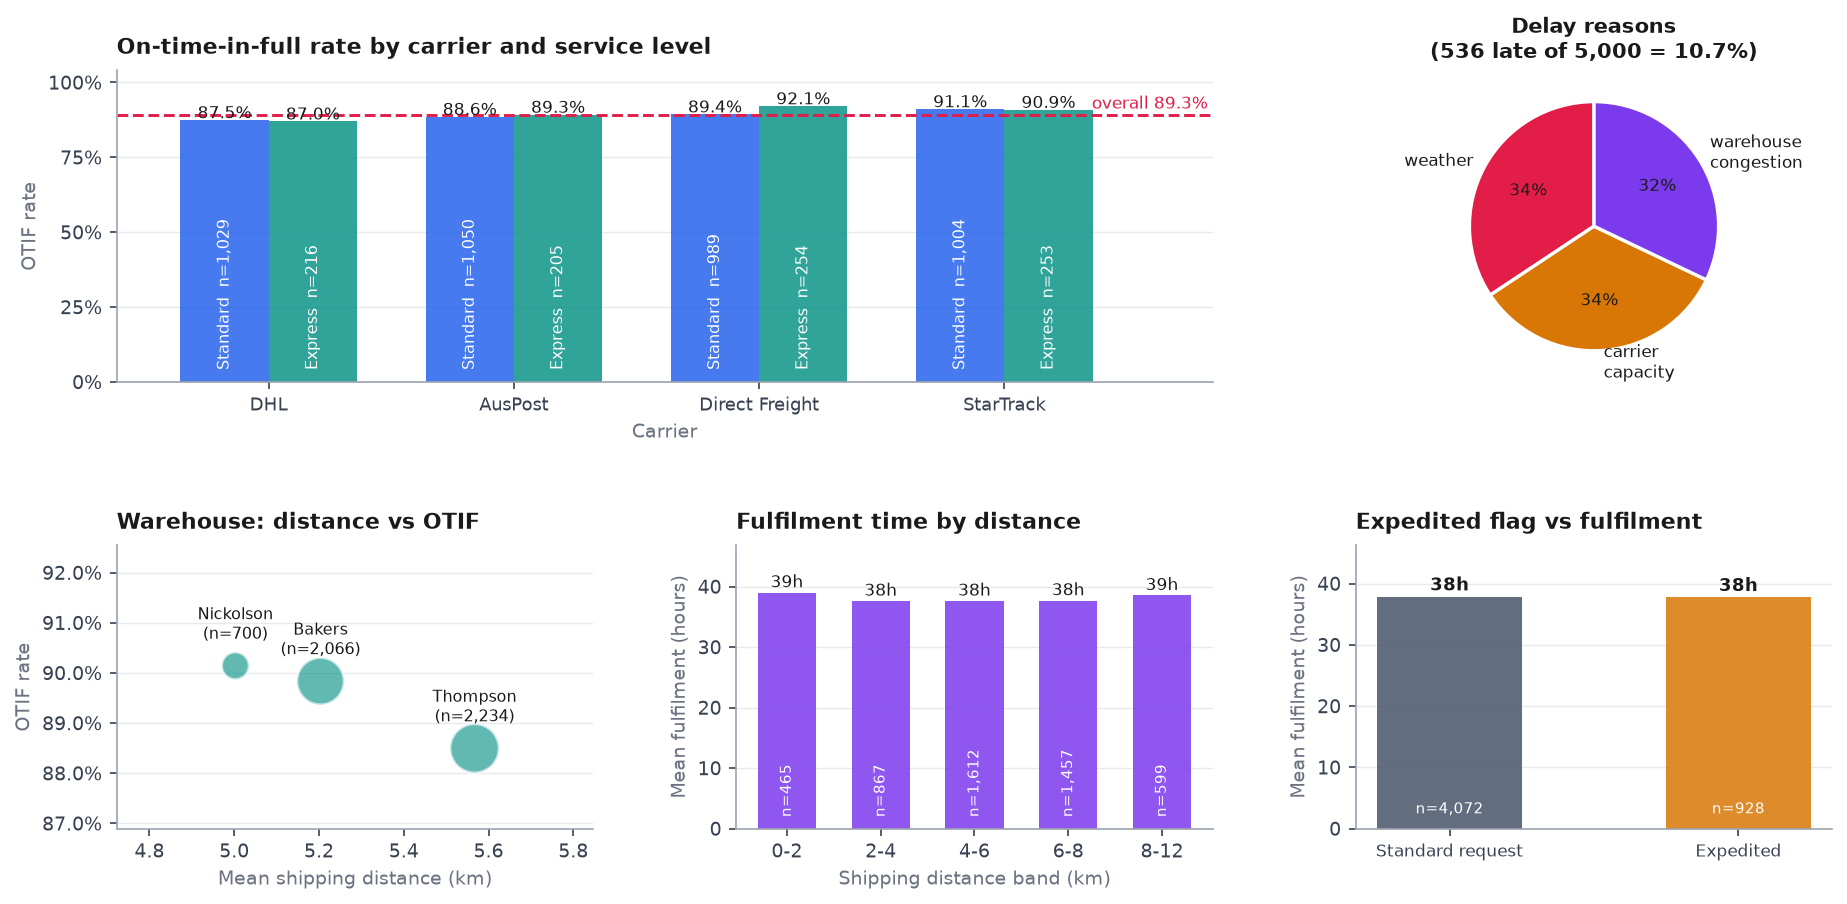

saved Figure_7.png and Figure_7_delivery_operational_performance.png


In [10]:
# =============================================================================
# FIGURE 7 - delivery / operational performance  (JOIN deliveries -> orders)
# =============================================================================
print("Figure 7 ...")
before = len(deliveries)
do = deliveries.merge(orders[["order_id", "nearest_warehouse", "sales_channel",
                              "expedited_delivery", "order_total"]],
                      on="order_id", how="left", validate="one_to_one")
print(f"  grain check: deliveries {before:,} -> after join {len(do):,} "
      f"(one_to_one on order_id; unchanged)")

fig = plt.figure(figsize=(12.5, 7.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1], hspace=0.55, wspace=0.30,
                      left=0.070, right=0.985, top=0.855, bottom=0.190)

ax = fig.add_subplot(gs[0, :2])
piv = do.pivot_table(index="carrier", columns="service_level",
                     values="on_time_in_full", aggfunc="mean") * 100
cnt = do.pivot_table(index="carrier", columns="service_level",
                     values="order_id", aggfunc="count")
piv = piv.loc[piv.mean(axis=1).sort_values().index]
x = np.arange(len(piv))
w = 0.36
for k, sl in enumerate(["Standard", "Express"]):
    bars = ax.bar(x + (k - 0.5) * w, piv[sl], w, color=[BLUE, TEAL][k],
                  alpha=0.85, label=f"{sl}")
    for b, v, n in zip(bars, piv[sl], cnt.loc[piv.index, sl]):
        ax.text(b.get_x() + b.get_width()/2, v + 0.6, f"{v:.1f}%",
                ha="center", fontsize=8, color=INK)
        ax.text(b.get_x() + b.get_width()/2, 4, f"{sl}  n={n:,}", ha="center",
                va="bottom", fontsize=7.6, color="white", rotation=90)
overall = do.on_time_in_full.mean() * 100
ax.axhline(overall, color=ROSE, ls="--", lw=1.4)
ax.set_xlim(-0.62, 3.85)
ax.text(3.83, overall + 2.0, f"overall {overall:.1f}%",
        fontsize=8, color=ROSE, ha="right")
ax.set_xticks(x)
ax.set_xticklabels(piv.index, fontsize=8.8)
ax.set_ylim(0, 104)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_locator(MaxNLocator(5))
finish(ax, "On-time-in-full rate by carrier and service level",
       "Carrier", "OTIF rate")
car = (do.groupby("carrier").on_time_in_full.mean() * 100).sort_values()

ax = fig.add_subplot(gs[0, 2])
dr = do.loc[do.delay_reason != "none", "delay_reason"].value_counts()
ax.pie(dr.values, labels=[l.replace("_", "\n") for l in dr.index],
       autopct=lambda p: f"{p:.0f}%", colors=[ROSE, AMBER, VIOLET],
       startangle=90, textprops=dict(fontsize=8.2),
       wedgeprops=dict(edgecolor="white", linewidth=1.6))
ax.set_title(f"Delay reasons\n({dr.sum():,} late of {len(do):,} = "
             f"{100*dr.sum()/len(do):.1f}%)",
             fontsize=10, fontweight="bold", loc="center", pad=6)
ax.grid(False)

ax = fig.add_subplot(gs[1, 0])
wh = do.groupby("nearest_warehouse").agg(
    otif=("on_time_in_full", "mean"), dist=("shipping_distance_km", "mean"),
    n=("order_id", "count"))
ax.scatter(wh.dist, wh.otif * 100, s=wh.n / 4, color=TEAL, alpha=0.65,
           edgecolors="white", linewidth=1.4)
for name, row in wh.iterrows():
    ax.annotate(f"{name}\n(n={int(row.n):,})", (row.dist, row.otif * 100),
                fontsize=7.8, ha="center", xytext=(0, 13),
                textcoords="offset points", color=INK)
ax.set_xlim(wh.dist.min() - 0.28, wh.dist.max() + 0.28)
ax.set_ylim(wh.otif.min() * 100 - 1.6, wh.otif.max() * 100 + 2.4)
ax.yaxis.set_major_formatter(PercentFormatter())
finish(ax, "Warehouse: distance vs OTIF", "Mean shipping distance (km)",
       "OTIF rate")

ax = fig.add_subplot(gs[1, 1])
bins = [0, 2, 4, 6, 8, 12]
do["dist_band"] = pd.cut(do.shipping_distance_km, bins=bins,
                         labels=["0-2", "2-4", "4-6", "6-8", "8-12"])
g = do.groupby("dist_band", observed=True).agg(
    hrs=("fulfilment_hours", "mean"), n=("order_id", "count"))
ax.bar(g.index.astype(str), g.hrs, color=VIOLET, alpha=0.85, width=0.62)
for k, (v, n) in enumerate(zip(g.hrs, g.n)):
    ax.text(k, v + 0.9, f"{v:.0f}h", ha="center", fontsize=8.2, color=INK)
    ax.text(k, 2.5, f"n={n:,}", ha="center", fontsize=7.2, color="white",
            rotation=90)
ax.set_ylim(0, g.hrs.max() * 1.20)
finish(ax, "Fulfilment time by distance", "Shipping distance band (km)",
       "Mean fulfilment (hours)")

ax = fig.add_subplot(gs[1, 2])
exp = do.groupby("expedited_delivery").agg(
    hrs=("fulfilment_hours", "mean"), otif=("on_time_in_full", "mean"),
    n=("order_id", "count"))
exp.index = ["Standard request", "Expedited"]
x = np.arange(2)
ax.bar(x, exp.hrs, 0.5, color=[SLATE, AMBER], alpha=0.85)
for k, (v, n) in enumerate(zip(exp.hrs, exp.n)):
    ax.text(k, v + 1.0, f"{v:.0f}h", ha="center", fontsize=8.5,
            fontweight="bold")
    ax.text(k, 2.5, f"n={int(n):,}", ha="center", fontsize=7.4, color="white")
ax.set_xticks(x)
ax.set_xticklabels(exp.index, fontsize=8.4)
ax.set_ylim(0, exp.hrs.max() * 1.22)
finish(ax, "Expedited flag vs fulfilment", None, "Mean fulfilment (hours)")

frame(fig, 7, "Where does delivery performance actually vary?",
      f"one row per completed order delivery; denominator = {len(do):,} deliveries ({int((~do.on_time_in_full).sum()):,} late, {100*(~do.on_time_in_full).mean():.1f}%)",
      "deliveries \u22c8 orders on order_id (one-to-one; row count verified unchanged at 5,000)",
      f"Result: OTIF is {overall:.1f}% overall and remarkably uniform - the carrier spread is only {car.max()-car.min():.1f} points "
      f"({car.index[0]} {car.iloc[0]:.1f}% to {car.index[-1]} {car.iloc[-1]:.1f}%) and Express barely differs from Standard, so service "
      f"level is not buying reliability. Delay causes split near-evenly across weather, carrier capacity and warehouse congestion "
      f"({', '.join(f'{i.replace(chr(95),chr(32))} {100*v/dr.sum():.0f}%' for i, v in dr.items())}), meaning no single fixable bottleneck dominates.\n"
      "Limitation: shipping distance spans only 0.5-10.1 km across three metropolitan warehouses, far too narrow a range to test a distance "
      "effect on fulfilment time. Carrier is not randomly assigned, so any carrier gap may reflect route or product mix rather than performance.")
save(fig, 7, "delivery_operational_performance")

## Figure 8 — Does delivery performance shape customer ratings?

**Observation unit and denominator.** One review; 7,000 reviews covering 4,044 distinct orders.  
**Tables and join keys.** `product_reviews` joined to `deliveries` on `order_id` (many-to-one); the review count remains 7,000.  
**Why this visualisation.** Rating means with 95% intervals, full rating composition and operational subgroups test whether a small mean difference hides a distributional change.  
**Interpretation and explanation.** Rating means and the 1–5 star mix are almost unchanged by OTIF, delay days, service level and delay reason. The result supports a weak association in this observed reviewer sample, not evidence that delivery quality never matters.  
**Material limitation.** Reviews from the same order are not independent and only reviewed orders are observed; the displayed review-level confidence intervals may therefore be optimistic.

Figure 8 ...
  grain check: product_reviews 7,000 -> after join 7,000 (many_to_one on order_id; unchanged)
  note: 4,044 distinct orders carry the 7,000 reviews (mean 1.73 reviews per reviewed order) - delivery attributes therefore repeat across sibling reviews and must NOT be aggregated as if one row per delivery


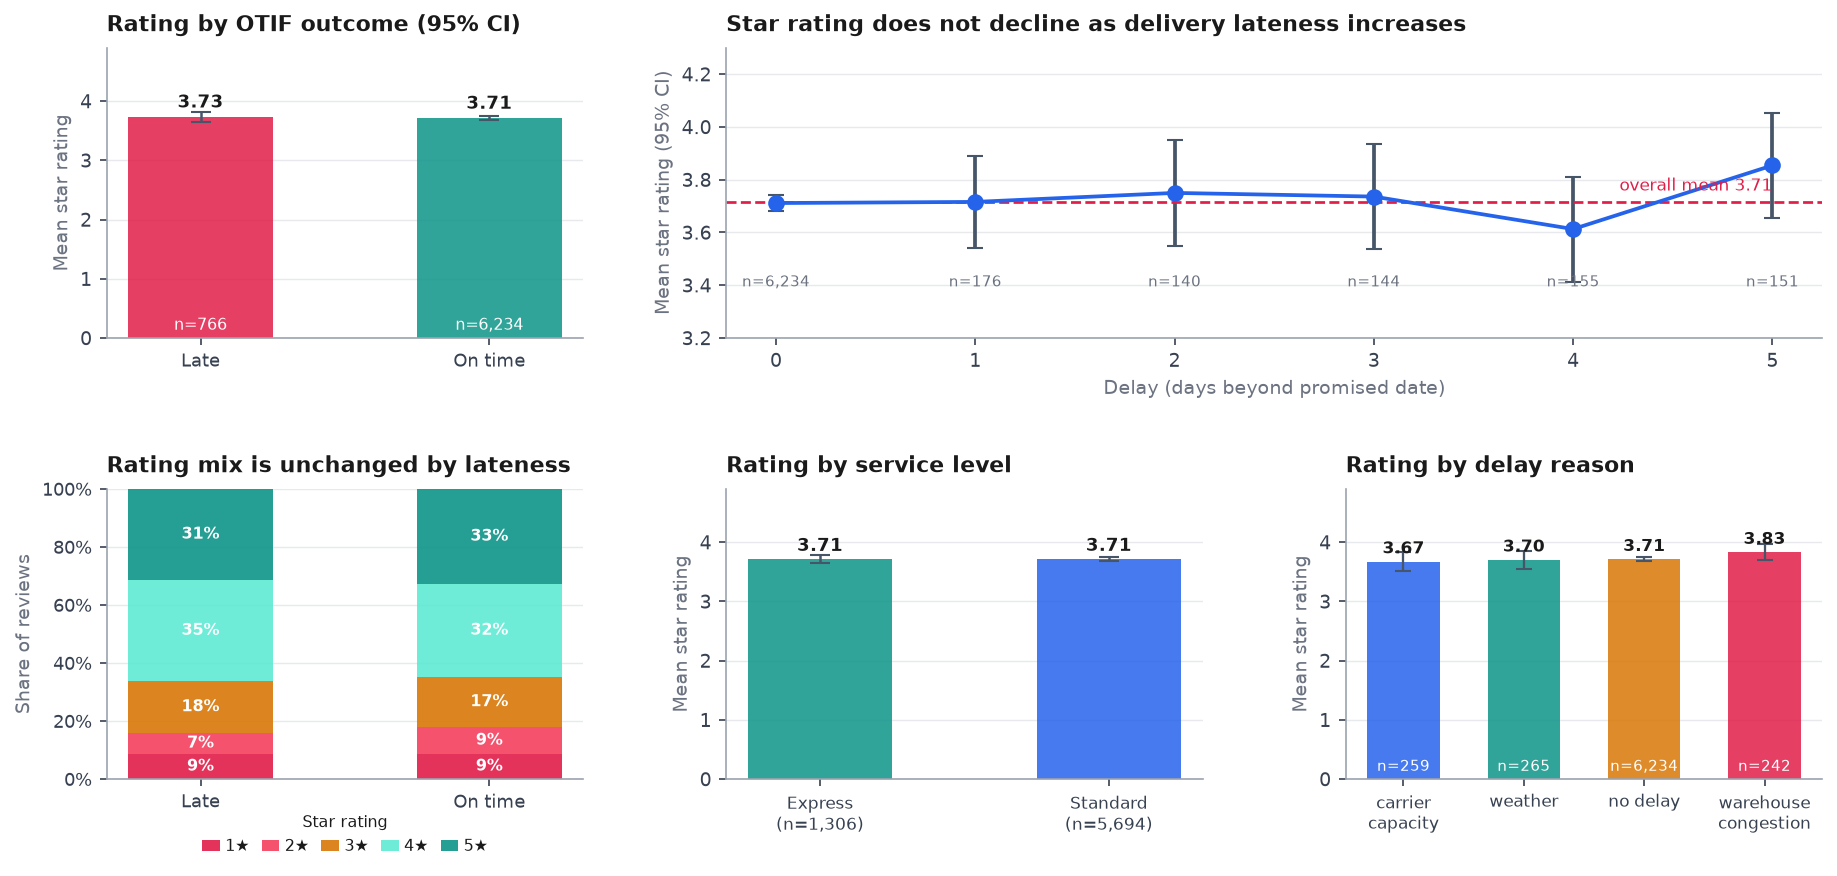

saved Figure_8.png and Figure_8_delivery_impact_on_reviews.png


In [11]:
# =============================================================================
# FIGURE 8 - does delivery performance shape reviews?  (JOIN reviews->deliveries)
# =============================================================================
print("Figure 8 ...")
before = len(reviews)
rd = reviews.merge(
    deliveries[["order_id", "delay_days", "on_time_in_full", "service_level",
                "carrier", "shipping_distance_km", "delay_reason"]],
    on="order_id", how="left", validate="many_to_one")
print(f"  grain check: product_reviews {before:,} -> after join {len(rd):,} "
      f"(many_to_one on order_id; unchanged)")
print(f"  note: {reviews.order_id.nunique():,} distinct orders carry the 7,000 reviews "
      f"(mean {len(reviews)/reviews.order_id.nunique():.2f} reviews per reviewed order) - "
      f"delivery attributes therefore repeat across sibling reviews and must NOT be "
      f"aggregated as if one row per delivery")

fig = plt.figure(figsize=(12.5, 7.8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.52, wspace=0.30,
                      left=0.070, right=0.985, top=0.855, bottom=0.230)

ax = fig.add_subplot(gs[0, 0])
g = rd.groupby("on_time_in_full").rating.agg(["mean", "sem", "count"])
g.index = ["Late", "On time"]
ax.bar(range(2), g["mean"], yerr=1.96 * g["sem"], capsize=5, width=0.5,
       color=[ROSE, TEAL], alpha=0.85, error_kw=dict(ecolor=SLATE, lw=1.2))
for k, (v, n) in enumerate(zip(g["mean"], g["count"])):
    ax.text(k, v + 0.16, f"{v:.2f}", ha="center", fontsize=8.8, fontweight="bold")
    ax.text(k, 0.14, f"n={int(n):,}", ha="center", fontsize=7.6, color="white")
ax.set_xticks(range(2))
ax.set_xticklabels(g.index, fontsize=8.8)
ax.set_ylim(0, 4.9)
finish(ax, "Rating by OTIF outcome (95% CI)", None, "Mean star rating")

ax = fig.add_subplot(gs[0, 1:])
g = rd.groupby("delay_days").rating.agg(["mean", "sem", "count"])
ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], fmt="o-", color=BLUE,
            lw=1.8, ms=7, capsize=4, ecolor=SLATE)
ax.axhline(reviews.rating.mean(), color=ROSE, ls="--", lw=1.3)
ax.text(g.index.max(), reviews.rating.mean() + 0.03,
        f"overall mean {reviews.rating.mean():.2f}", fontsize=8, color=ROSE,
        ha="right", va="bottom")
for x_, m, n in zip(g.index, g["mean"], g["count"]):
    ax.text(x_, ax.get_ylim()[0], f"n={int(n):,}", ha="center", va="bottom",
            fontsize=7.4, color=MUTED)
ax.set_xticks(g.index)
ax.set_ylim(3.2, 4.3)
finish(ax, "Star rating does not decline as delivery lateness increases",
       "Delay (days beyond promised date)", "Mean star rating (95% CI)")

ax = fig.add_subplot(gs[1, 0])
mix = pd.crosstab(rd.on_time_in_full, rd.rating, normalize="index") * 100
mix.index = ["Late", "On time"]
bottom = np.zeros(len(mix))
star_cols = [ROSE, "#f43f5e", AMBER, "#5eead4", TEAL]
for k, star in enumerate(sorted(mix.columns)):
    ax.bar(mix.index, mix[star], 0.5, bottom=bottom, color=star_cols[k],
           alpha=0.90, label=f"{star}\u2605")
    for j, v in enumerate(mix[star]):
        if v > 5:
            ax.text(j, bottom[j] + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=7.6, color="white", fontweight="bold")
    bottom += mix[star].values
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(fontsize=7.6, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.075),
          columnspacing=0.8, handlelength=1.1, handletextpad=0.35,
          title="Star rating", title_fontsize=7.6)
finish(ax, "Rating mix is unchanged by lateness", None, "Share of reviews")
ax.tick_params(labelsize=8.6)

ax = fig.add_subplot(gs[1, 1])
g = rd.groupby("service_level").rating.agg(["mean", "sem", "count"])
ax.bar(range(len(g)), g["mean"], yerr=1.96 * g["sem"], capsize=5, width=0.5,
       color=[TEAL, BLUE], alpha=0.85, error_kw=dict(ecolor=SLATE, lw=1.2))
ax.set_xticks(range(len(g)))
ax.set_xticklabels([f"{i}\n(n={int(n):,})" for i, n in zip(g.index, g["count"])],
                   fontsize=8.4)
for k, v in enumerate(g["mean"]):
    ax.text(k, v + 0.14, f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")
ax.set_ylim(0, 4.9)
finish(ax, "Rating by service level", None, "Mean star rating")

ax = fig.add_subplot(gs[1, 2])
g = rd.groupby("delay_reason").rating.agg(["mean", "sem", "count"]).sort_values("mean")
lbl = {"none": "no delay", "carrier_capacity": "carrier\ncapacity",
       "warehouse_congestion": "warehouse\ncongestion", "weather": "weather"}
ax.bar(range(len(g)), g["mean"], yerr=1.96 * g["sem"], capsize=4, width=0.6,
       color=[SEQ[i] for i in range(len(g))], alpha=0.85,
       error_kw=dict(ecolor=SLATE, lw=1.1))
ax.set_xticks(range(len(g)))
ax.set_xticklabels([lbl.get(i, i) for i in g.index], fontsize=8)
for k, (v, n) in enumerate(zip(g["mean"], g["count"])):
    ax.text(k, v + 0.14, f"{v:.2f}", ha="center", fontsize=8.2, fontweight="bold")
    ax.text(k, 0.14, f"n={int(n):,}", ha="center", fontsize=7.2, color="white")
ax.set_ylim(0, 4.9)
finish(ax, "Rating by delay reason", None, "Mean star rating")

frame(fig, 8, "Does delivery performance shape customer ratings?",
      "one row per review; denominator = 7,000 reviews covering 4,044 distinct orders",
      "product_reviews \u22c8 deliveries on order_id (many-to-one; rows unchanged at 7,000)",
      f"Result: a clean null across every operational cut. Late deliveries score {rd[~rd.on_time_in_full].rating.mean():.2f} vs "
      f"{rd[rd.on_time_in_full].rating.mean():.2f} for on-time, the rating mix is visually identical, ratings are flat from 0 to 5 days late "
      f"with overlapping confidence intervals, and service level and delay reason make no difference. Yet stated delivery_experience matches "
      f"the recorded OTIF flag on {100*((rd.delivery_experience=='delayed')==(~rd.on_time_in_full)).mean():.1f}% of reviews, so the operational "
      f"data is reported faithfully - it simply does not transfer to the star rating.\n"
      "Limitation: reviews are many-to-one onto deliveries (1.73 reviews per reviewed order), so delivery attributes repeat across sibling "
      "reviews and rows are not independent - the confidence intervals above are therefore optimistic. Only 4,044 of 5,000 orders were "
      "reviewed, and non-reviewers may be exactly the dissatisfied group, which is a survivorship risk this data cannot resolve.")
save(fig, 8, "delivery_impact_on_reviews")

## 4. Coverage register

This register is a final check that the eight assessed figures collectively satisfy the required coverage. A coordinated set of panels is counted as one figure only when the panels answer the same question.

In [12]:
figure_register = pd.DataFrame([
    [1, "Univariate distribution/composition", "orders", "none", "order"],
    [2, "Bivariate and customer comparison", "orders; customers", "customer_id", "order / customer"],
    [3, "Multivariate category analysis", "order_items; products", "product_id", "order-item line"],
    [4, "Temporal pattern", "orders", "none", "order aggregated by time"],
    [5, "Review/text behaviour", "product_reviews", "none", "review"],
    [6, "Review/text behaviour", "product_reviews", "none", "review"],
    [7, "Delivery/operational performance", "deliveries; orders", "order_id", "delivery"],
    [8, "Delivery-review relationship", "product_reviews; deliveries", "order_id", "review"],
], columns=["figure", "category", "tables", "join_key", "grain"])
assert len(figure_register) == 8
assert figure_register.tables.str.contains("orders|order_items|customers|deliveries|products|product_reviews").all()
figure_register

,figure,category,tables,join_key,grain
0,1,Univariate distribution/composition,orders,none,order
1,2,Bivariate and customer comparison,orders; customers,customer_id,order / customer
2,3,Multivariate category analysis,order_items; products,product_id,order-item line
3,4,Temporal pattern,orders,none,order aggregated by time
4,5,Review/text behaviour,product_reviews,none,review
5,6,Review/text behaviour,product_reviews,none,review
6,7,Delivery/operational performance,deliveries; orders,order_id,delivery
7,8,Delivery-review relationship,product_reviews; deliveries,order_id,review


## 5. Ten evidence-based findings

1. **A typical order is materially below the mean.** At order grain (5,000 orders), Figure 1 shows a median total of **$2,555** versus a mean of **$3,000**, with the 99th percentile near **$11,823**. The right tail can overstate normal basket value if the mean is used alone. Different line-item counts are an alternative explanation for part of the tail, so operational reporting should pair median and upper percentiles rather than treating the mean as a customer norm.

2. **No sales channel dominates order count.** Figure 1 shows each of Cart, Store and Mobile contributing approximately **32–35% of 5,000 orders**. This reduces immediate dependence on one channel by volume, but the figure does not compare revenue, margin or acquisition cost. Channel strategy should therefore be evaluated with value and cost measures before reallocating investment.

3. **Customer labels provide little separation in basket value.** Across 5,000 orders joined many-to-one to 500 customers, Figure 2 shows customer-segment medians within about **$203** and loyalty-tier means around **$2,947–$3,038**, with overlapping 95% intervals. Within-group variation and repeated customers create uncertainty, so these labels should not be used alone for basket-value targeting; order context and product mix merit testing.

4. **Current-period customer revenue mainly tracks recorded order frequency.** At customer grain (500 customers), Figure 2 shows cumulative revenue rising closely with the number of 2018 orders and little visible loyalty-tier separation. This is commercially relevant for retention planning, but the relationship is partly mechanical because revenue is summed across orders and cannot establish that frequency causes value. Future modelling should predict future frequency using only information known before the prediction window.

5. **Category revenue and unit volume rank differently.** At order-item grain (15,723 lines; 41,993 units; **$16.12m** revenue), Figure 3 shows Home Entertainment and Laptop producing about **34.1% of revenue from 14.4% of units**, while Accessory has the largest unit share but only about **$0.61m** revenue. Price point explains much of this contrast, but revenue excludes cost and returns. Stock decisions should jointly consider units, revenue and contribution margin.

6. **Joining at the wrong grain would materially inflate an order metric.** The Figure 3 control shows that summing `order_total` after the orders–items fan-out would produce approximately **$53.19m**, or **3.55 times** the correct **$15.00m** order total. This is a relational calculation risk rather than a market pattern. Order metrics must be calculated before item-level joins and reconciled to a control total.

7. **Demand structure is intraday rather than strongly seasonal in this extract.** Across 5,000 orders in 2018, Figure 4 shows monthly counts between **406 and 438** (a **7.9%** peak-to-trough band) and similar weekday/weekend rates, while order counts collapse overnight. One year and unknown timezone limit generalisation. Staffing experiments should begin with hour-of-day demand and be revalidated on later periods.

8. **Review ratings are positive, but text length is mainly a writing-style property.** Among 7,000 reviews, Figure 5 shows **64.9%** at 4–5 stars versus **17.6%** at 1–2 stars; median length is about **433 characters** for concise and **1,572** for narrative reviews, while mean length and helpful votes are broadly flat across ratings. Because style is supplied rather than inferred and helpful votes lack exposure, text models should preserve style controls and avoid treating raw vote totals as intrinsic quality.

9. **Whitespace word counts are not directly comparable across scripts.** Figure 6 covers 7,000 reviews, including **303 non-Latin-script reviews**, and shows that character length and whitespace-token count move differently by script class. The small and heterogeneous subgroup makes the exact difference uncertain, but it is large enough to affect feature engineering. Character-based or language-aware text measures should be preferred, with performance reported by language/script group.

10. **Observed delivery variation does not translate into a clear rating difference.** At delivery grain, Figure 7 reports **89.3% OTIF across 5,000 deliveries** and only a **3.7 percentage-point** carrier spread; at review grain, Figure 8 shows late and on-time ratings of about **3.73 and 3.71** across 7,000 reviews with overlapping intervals. Carrier mix, clustered reviews and review-selection bias remain plausible explanations. Operational improvement should target service outcomes directly rather than assuming this cross-sectional rating signal measures customer impact.

## 6. Five future machine-learning questions

| Question | Business use case and unit/target | Decision-time predictors | Validation and metrics | Main risks and EDA grounding |
|---|---|---|---|---|
| **MLQ-1 — OTIF-failure classification** | Before dispatch, rank **orders** for intervention; target `on_time_in_full = False`. | Warehouse, carrier, service level, sales channel, expedited flag, order timestamp, item count/value, product weight and destination fields available before dispatch. | Forward time split by order date; PR-AUC and recall at a fixed intervention capacity, with ROC-AUC secondary. | Exclude delivered date, delay days/reason and realised fulfilment fields. Carrier assignment may encode operational policy. Figure 7 grounds the 10.7% event rate and weak simple group separation. |
| **MLQ-2 — Fulfilment-hours regression** | At order acceptance, estimate **hours per order** to support workload promises; target `fulfilment_hours`. | Order time, warehouse, channel, service level, expedited flag, item count, basket value, product mix, total weight and destination features available at acceptance. | Rolling/forward time split; MAE plus 90th-percentile absolute error. | Do not use dispatch/delivery dates or post-dispatch delay fields. Process changes can cause temporal drift. Figure 7 shows that distance bands and expedited status alone explain little variation. |
| **MLQ-3 — Low-rating classification** | At review invitation time, identify **reviewed orders** at risk of a 1–2 star rating; target whether order-level mean rating is at most 2. | Pre-invitation order, product/category, customer-history and completed-delivery fields; text and the eventual rating are excluded. | Forward split by delivery/review date, grouped by customer; PR-AUC, Brier score and recall at fixed contact capacity. | Review propensity creates selection bias; sensitive customer proxies require subgroup checks. Figures 5 and 8 show class imbalance and weak delivery-only separation. |
| **MLQ-4 — Future customer-frequency regression** | At a period boundary, forecast **next-period order count per customer** for retention planning; target future count. | Only customer attributes and aggregates from periods ending before the boundary: recency, historical frequency/value, channel mix, category breadth and prior delivery experience. | Rolling-origin temporal validation; MAE and Poisson deviance, compared with a recency-frequency baseline. | Random splits and lifetime fields can leak the future; new customers need a fallback. Figure 2 shows current revenue is closely associated with frequency but tier alone adds little visible separation. |
| **MLQ-5 — Product clustering** | Group **products** for assortment and inventory review; unsupervised objective: stable, interpretable product segments. | Catalogue attributes plus pre-cut-off price, cost, weight and historical unit/revenue summaries; scale numeric features and encode category/brand carefully. | Fit on an earlier period and assess stability on a later period using adjusted Rand index; silhouette score and business interpretability as secondary criteria. | Dominant category labels and scaling can predetermine clusters; rare products may be unstable. Figure 3 motivates separating high-price/low-volume from low-price/high-volume products. |

## 7. Limitations and conclusion

The analysis describes one 2018 export and does not establish causal effects. Several intervals treat rows as independent even though customers can place several orders and an order can have several reviews; the related figures state this limitation explicitly. Review-based results also apply only to orders that generated reviews. Despite these constraints, the eight figures cover all six required EDA categories, use all six tables, and include four checked relational analyses. The main decision value lies in respecting table grain, separating price from volume, focusing operational planning on intraday demand, and avoiding strong targeting claims from weak group differences.

## References used for method choices

- National Institute of Standards and Technology. (n.d.). *Histogram*. In *NIST/SEMATECH e-Handbook of statistical methods*. https://www.itl.nist.gov/div898/handbook/eda/section3/histogra.htm

External material informed general chart selection only. All numerical claims, findings and ML motivations above are calculated from the six Group030 standardised tables.